In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("solarpowergeneration (2) (1).csv")

In [3]:
df.head()

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [4]:
df.shape

(2920, 10)

In [5]:
df.ndim

2

In [6]:
df.size

29200

In [7]:
df.columns

Index(['distance-to-solar-noon', 'temperature', 'wind-direction', 'wind-speed',
       'sky-cover', 'visibility', 'humidity', 'average-wind-speed-(period)',
       'average-pressure-(period)', 'power-generated'],
      dtype='object')

In [8]:
df

,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069
...,...,...,...,...,...,...,...,...,...,...
2915,0.166453,63,27,13.9,4,10.0,75,10.0,29.93,6995
2916,0.064020,63,27,13.9,1,10.0,66,15.0,29.91,29490
2917,0.294494,63,27,13.9,2,10.0,68,21.0,29.88,17257
2918,0.524968,63,27,13.9,2,10.0,81,17.0,29.87,677


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   distance-to-solar-noon       2920 non-null   float64
 1   temperature                  2920 non-null   int64  
 2   wind-direction               2920 non-null   int64  
 3   wind-speed                   2920 non-null   float64
 4   sky-cover                    2920 non-null   int64  
 5   visibility                   2920 non-null   float64
 6   humidity                     2920 non-null   int64  
 7   average-wind-speed-(period)  2919 non-null   float64
 8   average-pressure-(period)    2920 non-null   float64
 9   power-generated              2920 non-null   int64  
dtypes: float64(5), int64(5)
memory usage: 228.3 KB


In [10]:
### Missing values
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    1
average-pressure-(period)      0
power-generated                0
dtype: int64

In [11]:
df.isnull().sum().sum()/len(df)*100

np.float64(0.03424657534246575)

In [12]:
len(df)

2920

#### Data Cleaning

In [13]:
### df.dropna(implace=True)
df['average-wind-speed-(period)'].fillna(df['average-wind-speed-(period)'].mean(), inplace=True)

In [14]:
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

In [15]:
df.columns = df.columns.str.replace('[^A-Za-z0-9]+', '_', regex=True)

In [16]:
### Checking Dupicates
df.duplicated().sum()

np.int64(0)

#### Data Visualization

In [17]:
num_cols = df.select_dtypes(include='number').columns

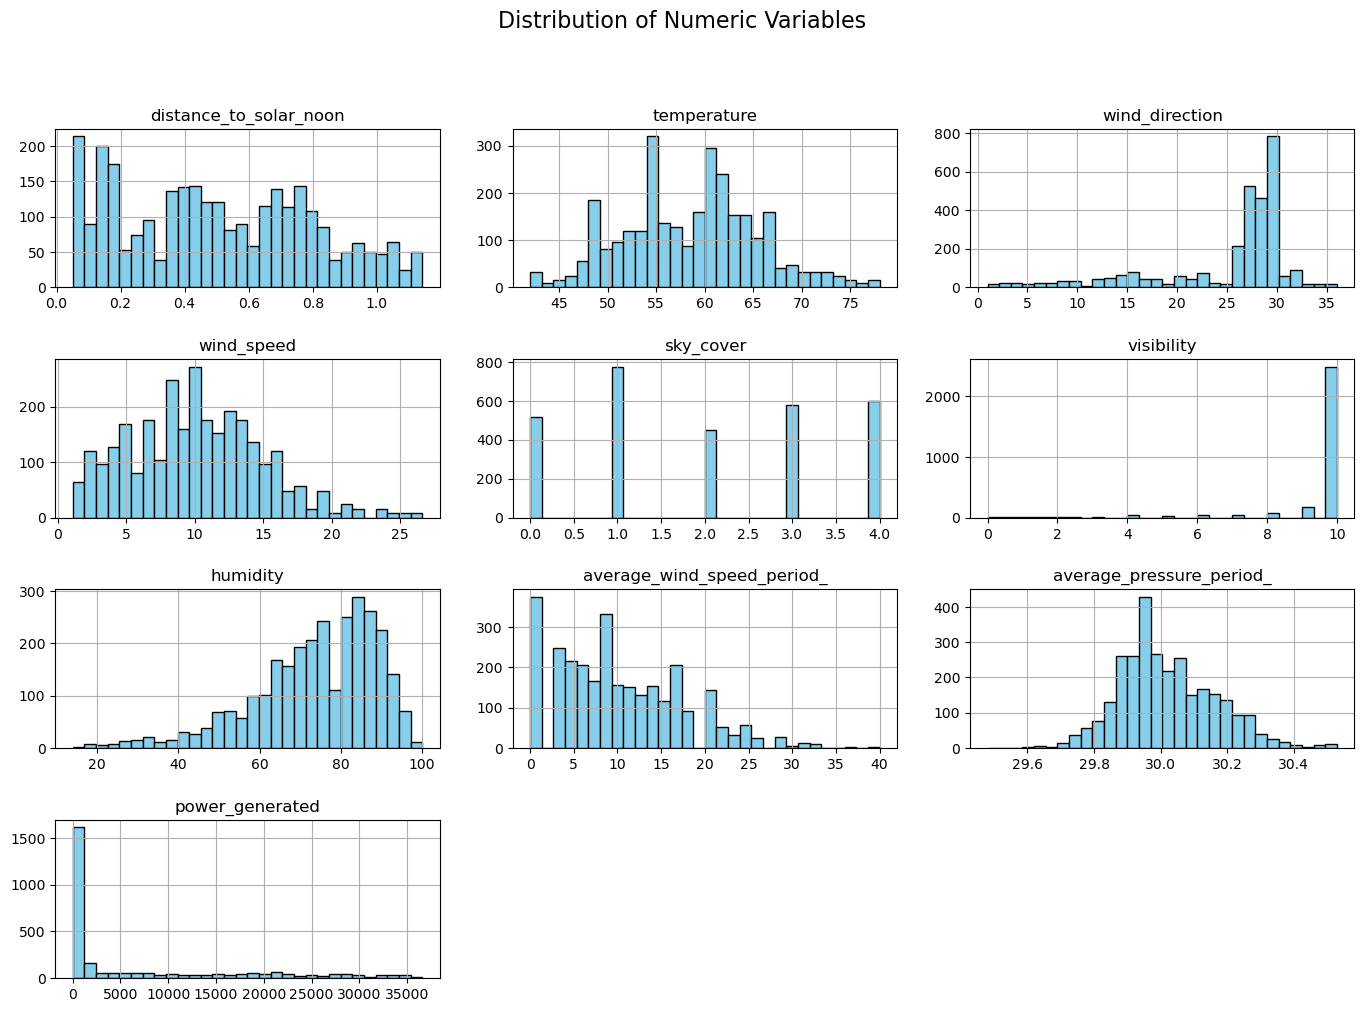

In [18]:
df[num_cols].hist(
    bins=30,
    figsize=(14, 10),
    color='skyblue',
    edgecolor='black',
    layout=(len(num_cols)//3 + 1, 3)
)
plt.suptitle("Distribution of Numeric Variables", fontsize=16, y=1.02)
plt.tight_layout(pad=2.0)
plt.show()

In [19]:
features = ['distance_to_solar_noon','temperature','wind_direction','wind_speed','sky_cover',
            'visibility','humidity','average_wind_speed_period_','average_pressure_period_']

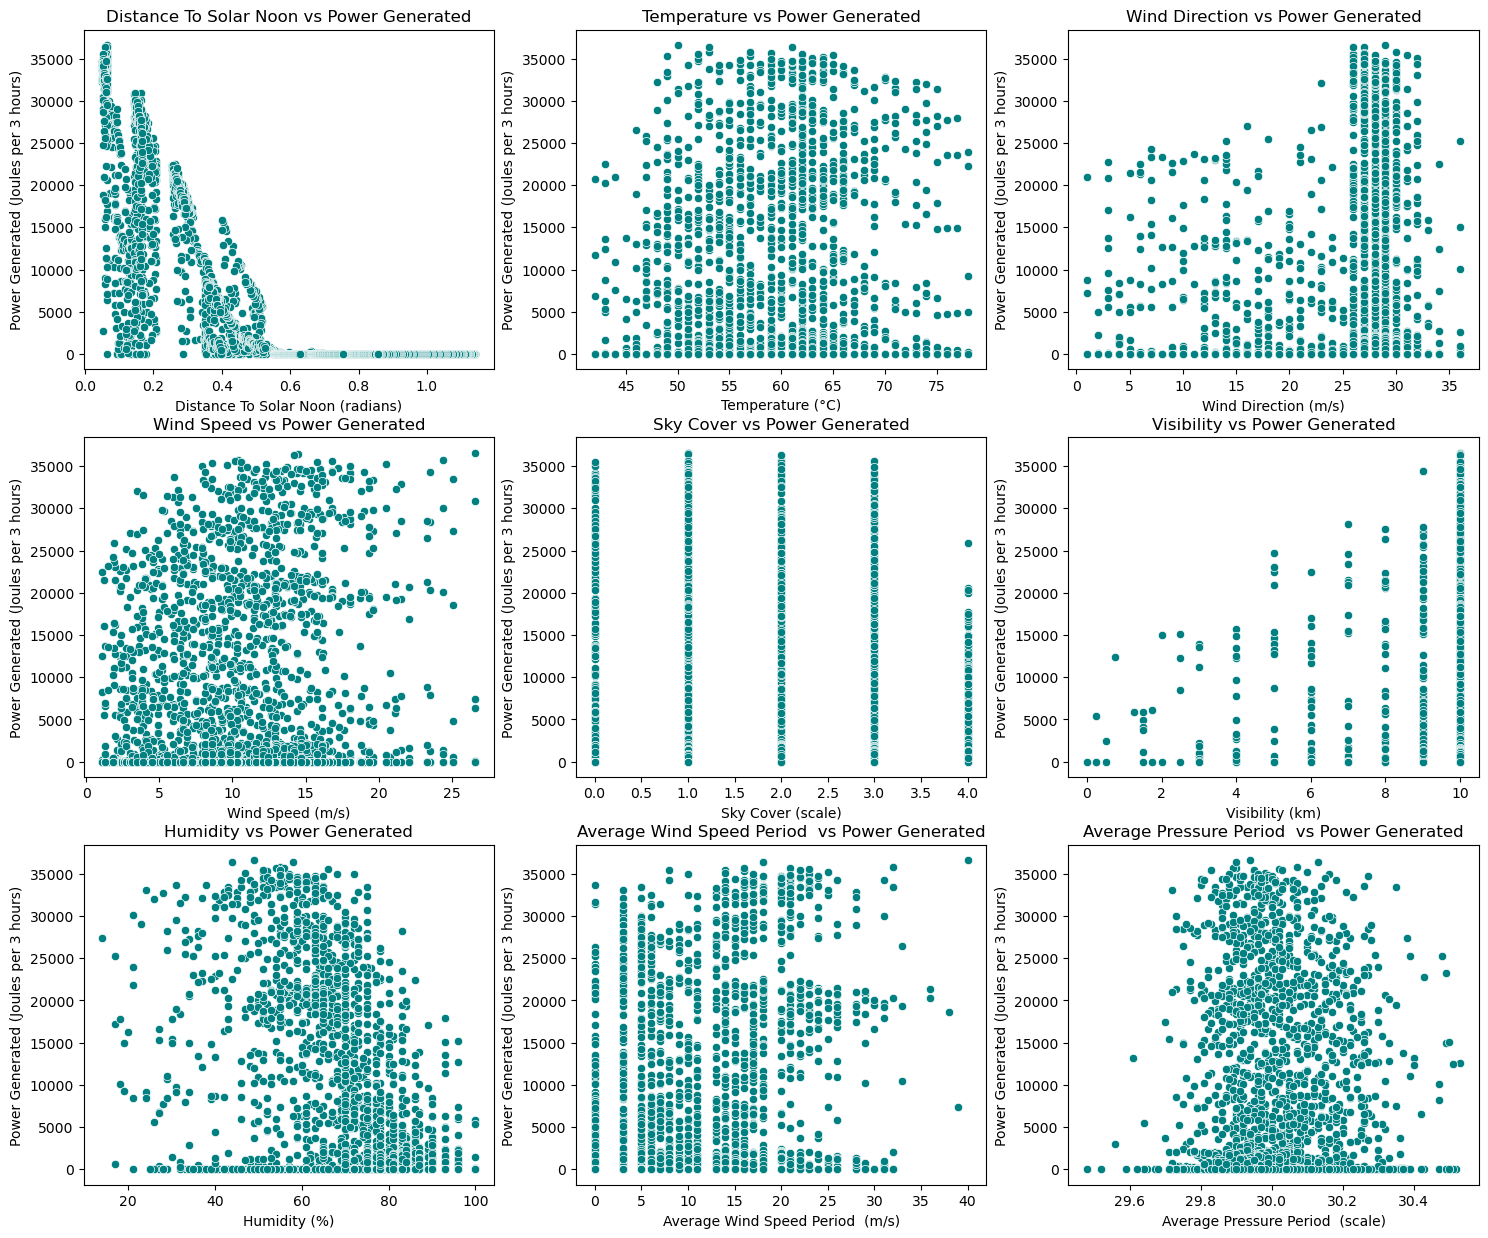

In [20]:
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.scatterplot(x=col, y='power_generated', data=df, ax=axes[i], color='teal')
    axes[i].set_title(f"{col.replace('_',' ').title()} vs Power Generated")
    axes[i].set_xlabel(f"{col.replace('_',' ').title()} ({'°C' if col=='temperature' else '%' if col=='humidity' else 'radians' if col=='distance_to_solar_noon' else 'km' if col=='visibility' else 'm/s' if 'wind' in col else 'scale'})")
    axes[i].set_ylabel("Power Generated (Joules per 3 hours)")

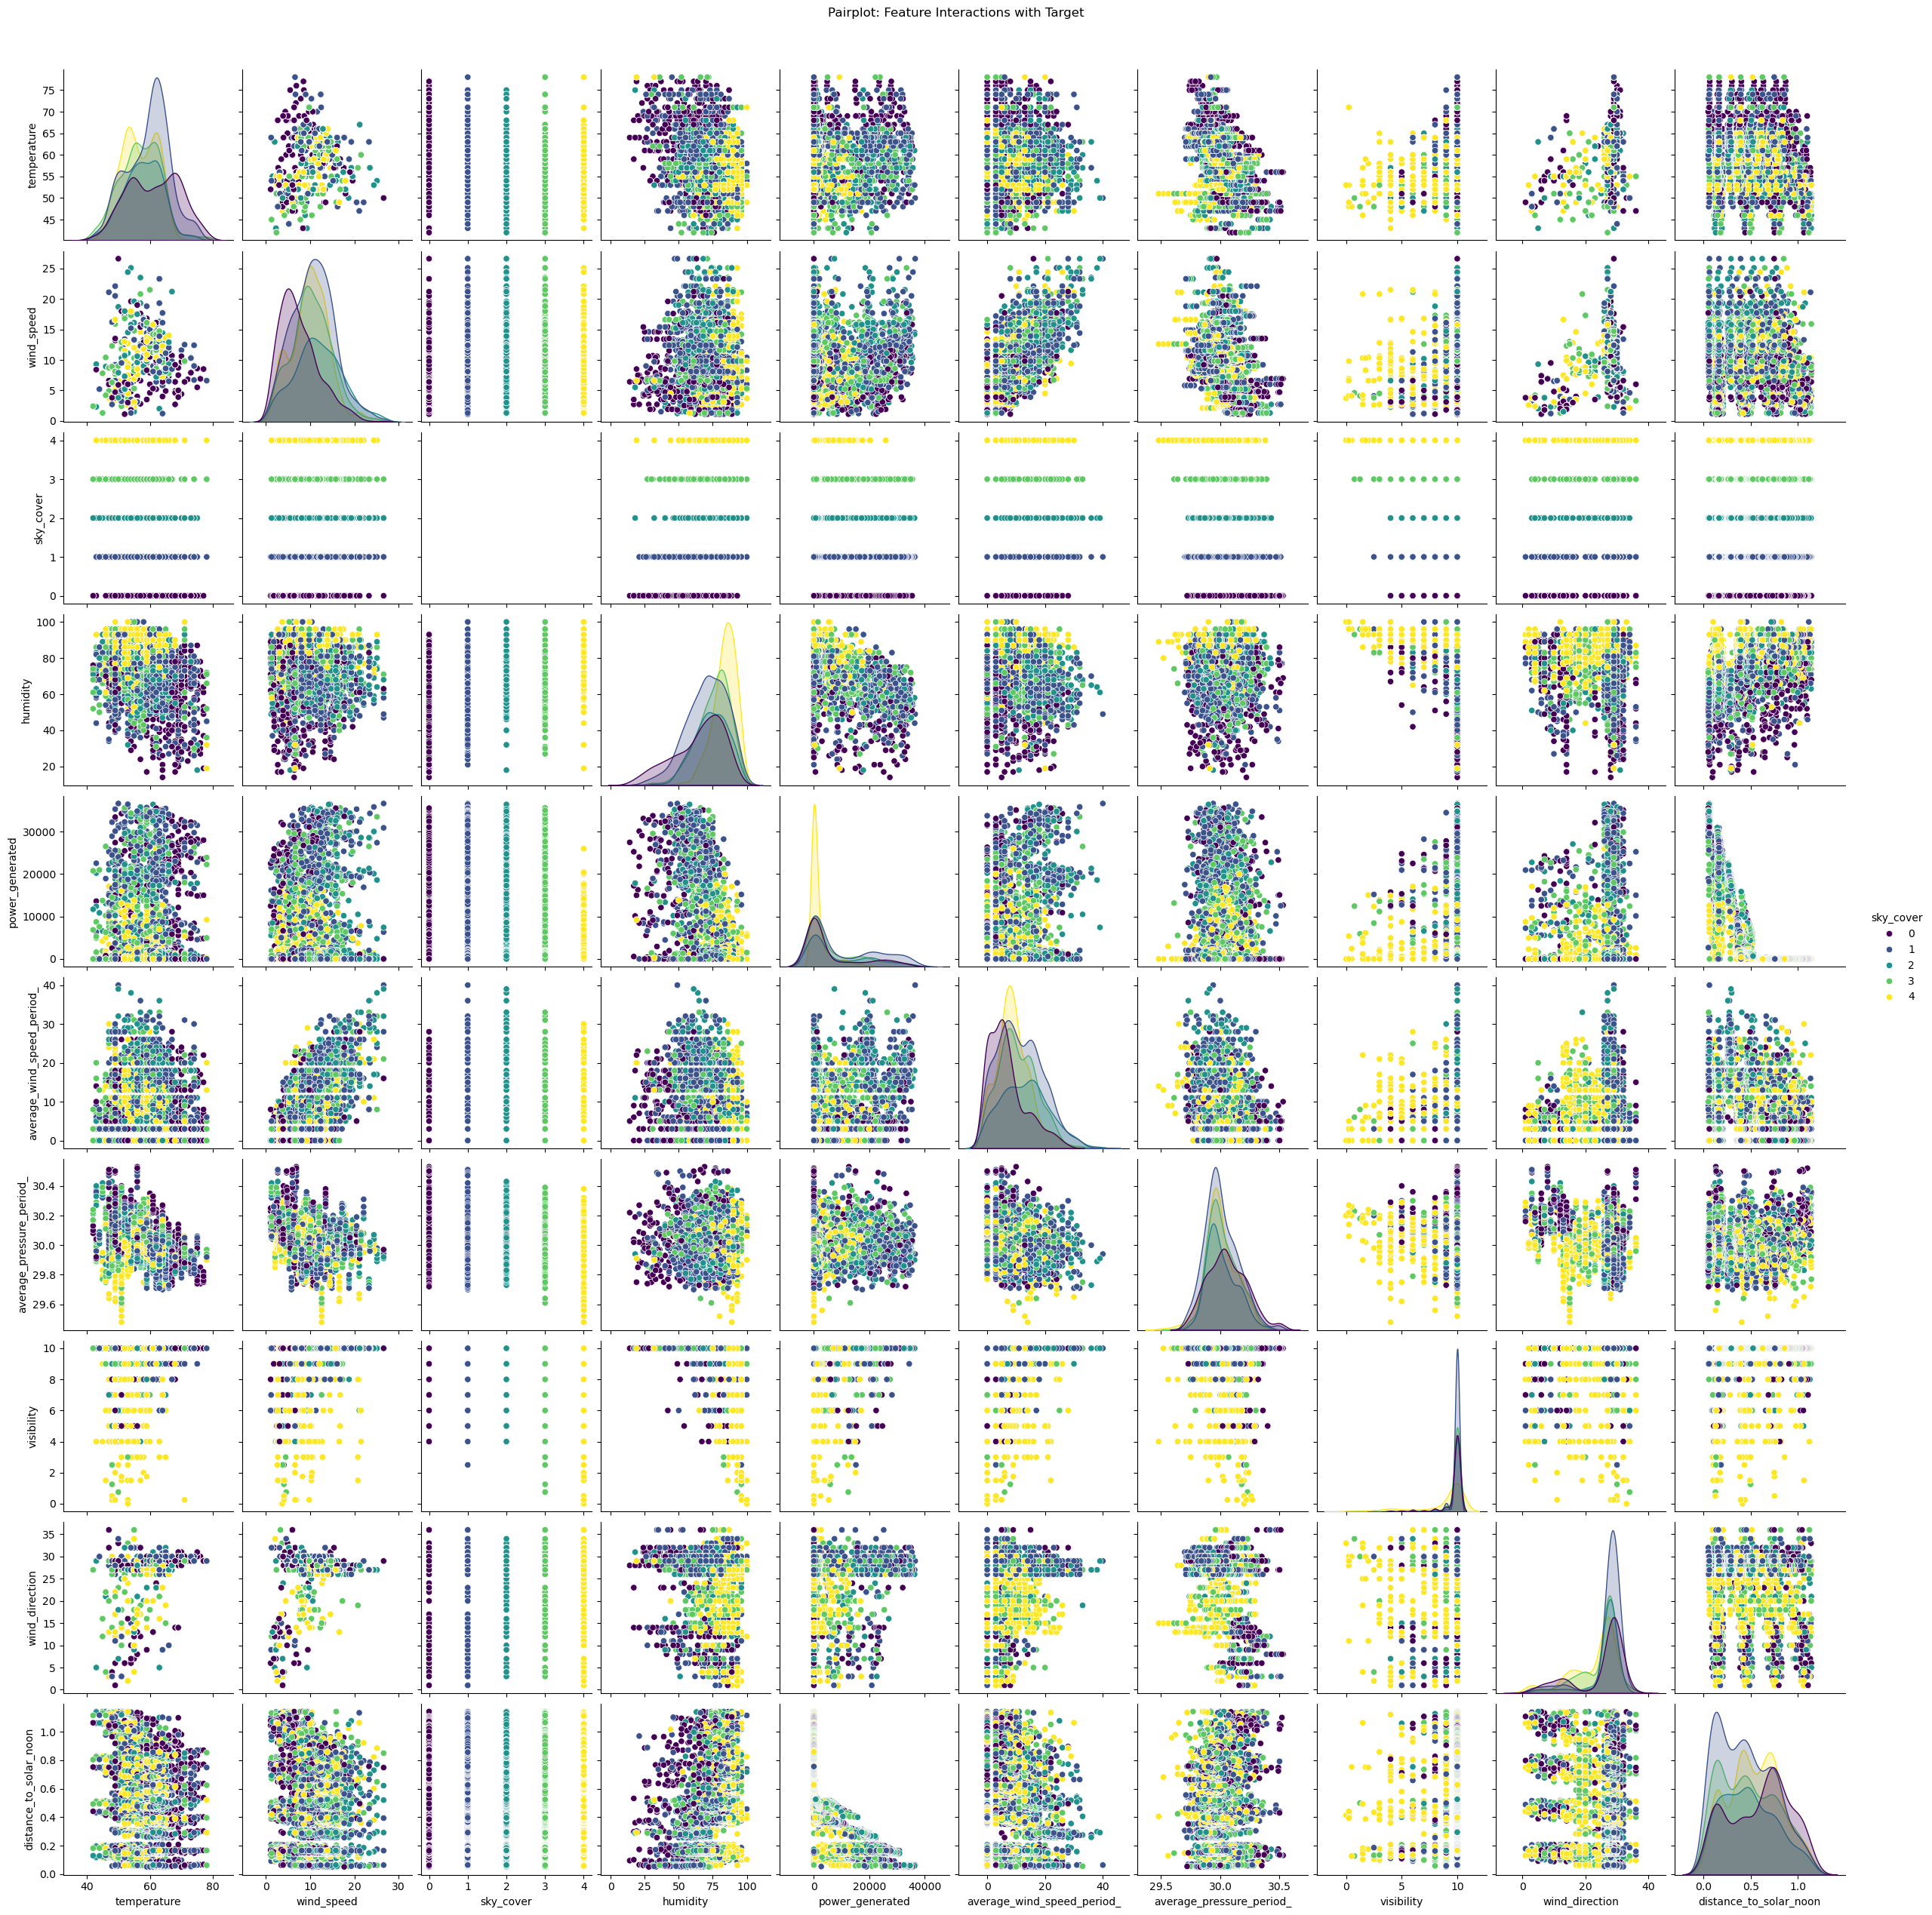

In [21]:
sns.pairplot(df, vars=['temperature', 'wind_speed', 'sky_cover', 'humidity', 'power_generated','average_wind_speed_period_','average_pressure_period_','visibility','wind_direction','distance_to_solar_noon'], hue='sky_cover', palette='viridis')
plt.suptitle('Pairplot: Feature Interactions with Target', y=1.02)
plt.show()

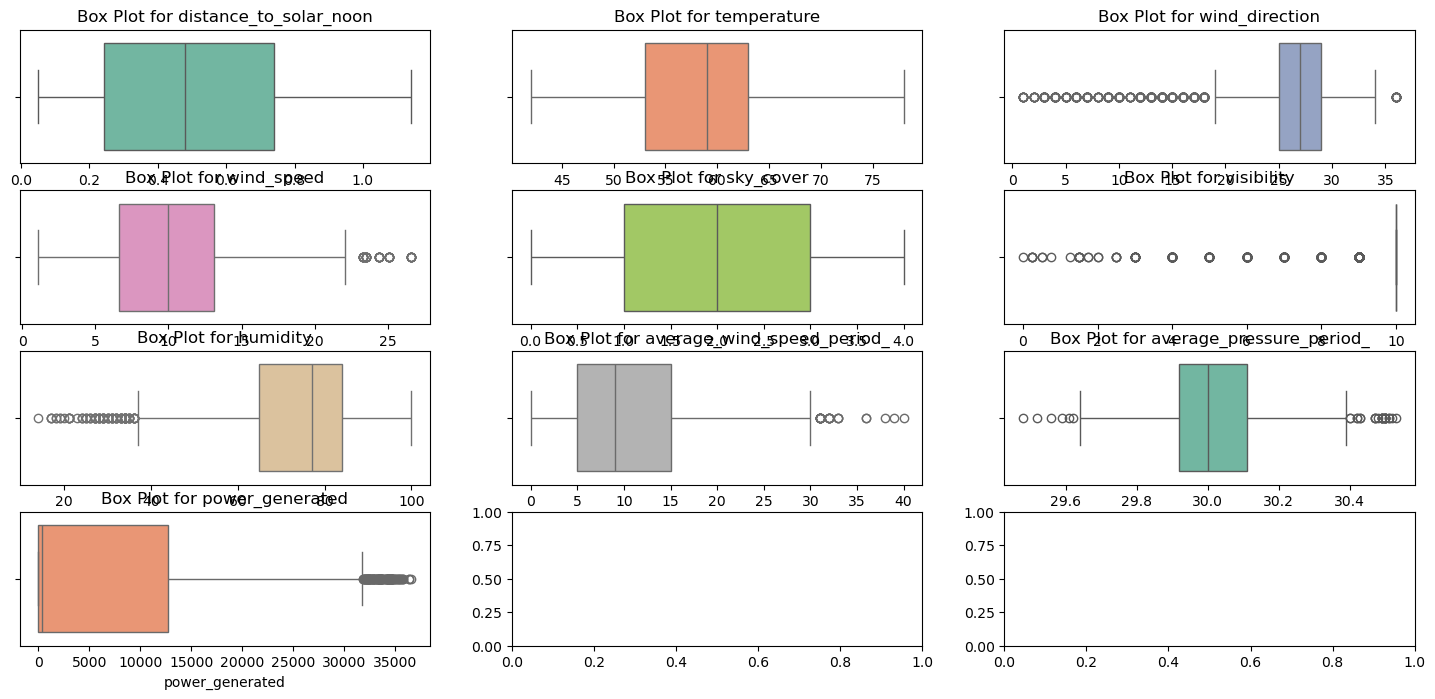

In [22]:
# box plots for outlier detection for all numeric columns
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2 * n_rows))
axes = axes.flatten()

colors = sns.color_palette("Set2", len(num_cols))

# Plot boxplots
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f'Box Plot for {col}')

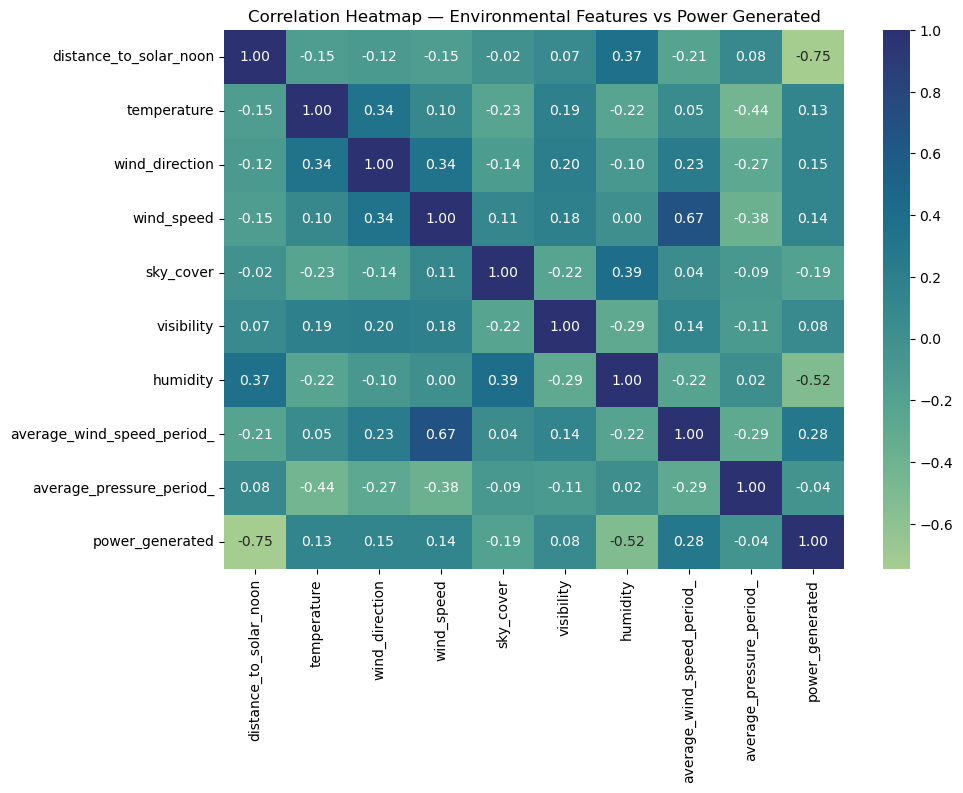

In [23]:
# Correlation heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='crest', fmt='.2f')
plt.title("Correlation Heatmap — Environmental Features vs Power Generated")
plt.show()

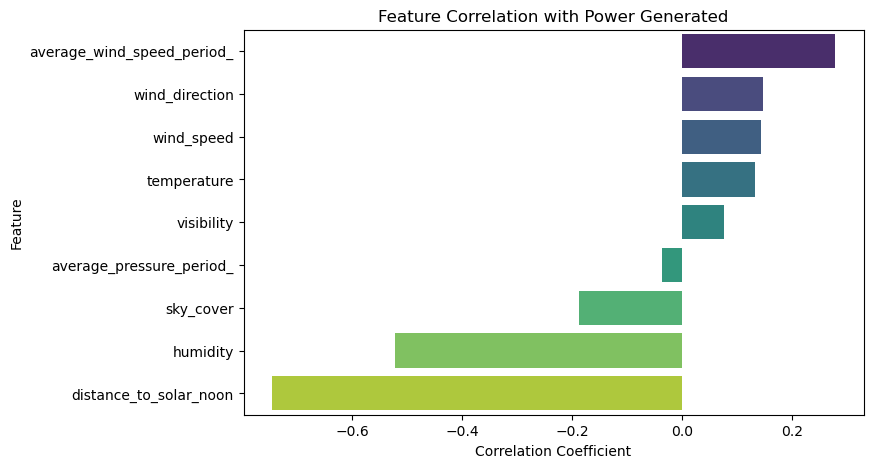

In [24]:
# Correlation part
corrs = df.corr()['power_generated'].drop('power_generated').sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=corrs.values, y=corrs.index, palette='viridis')
plt.title("Feature Correlation with Power Generated")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

In [38]:
### Feature Selection
final_list_columns = df[['distance_to_solar_noon', 'temperature', 'sky_cover', 'visibility', 'humidity', 'wind_speed','power_generated']]
print("final_list_columns shape:",final_list_columns.shape)

final_list_columns shape: (2920, 7)


In [39]:
# data selection or data partition
selected_features = ['distance_to_solar_noon','temperature','sky_cover','visibility','humidity','wind_speed']
X = df[selected_features]
y = df['power_generated']

In [40]:
# splitting the data into train and test splits
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training shape: {X_train.shape}, Testing shape: {X_test.shape}")

Training shape: (2336, 6), Testing shape: (584, 6)


In [41]:
### Standardization&Scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Model Building

In [43]:
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
### Linear Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
    }

In [46]:
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])
    print(f" {name} Results:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.4f}\n{'-'*40}")

 Linear Regression Results:
MAE: 5095.83
RMSE: 6352.59
R²: 0.6169
----------------------------------------
 Ridge Regression Results:
MAE: 5095.58
RMSE: 6352.60
R²: 0.6169
----------------------------------------
 Lasso Regression Results:
MAE: 5095.83
RMSE: 6352.59
R²: 0.6169
----------------------------------------


In [47]:
advanced_models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}
for name, model in advanced_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])
    print(f" {name} Results:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.4f}\n{'-'*40}")


 Random Forest Results:
MAE: 1562.99
RMSE: 3542.29
R²: 0.8809
----------------------------------------
 XGBoost Results:
MAE: 1606.60
RMSE: 3326.78
R²: 0.8949
----------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000711 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 539
[LightGBM] [Info] Number of data points in the train set: 2336, number of used features: 6
[LightGBM] [Info] Start training from score 7003.485445
 LightGBM Results:
MAE: 1780.35
RMSE: 3525.91
R²: 0.8820
----------------------------------------



 Model Comparison:
               Model          MAE         RMSE        R²
4            XGBoost  1606.600220  3326.778021  0.894933
5           LightGBM  1780.349570  3525.911111  0.881978
3      Random Forest  1562.991738  3542.294777  0.880879
2   Lasso Regression  5095.826196  6352.589533  0.616893
0  Linear Regression  5095.826335  6352.591487  0.616893
1   Ridge Regression  5095.576695  6352.599756  0.616892


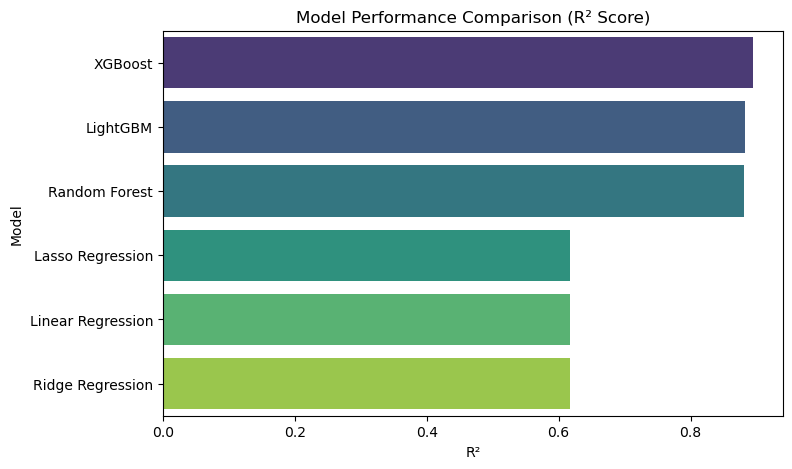

In [48]:
# Compile results
all_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
print("\n Model Comparison:")
print(all_results.sort_values(by="R²", ascending=False))

plt.figure(figsize=(8,5))
sns.barplot(data=all_results.sort_values("R²", ascending=False), x="R²", y="Model", palette="viridis")
plt.title("Model Performance Comparison (R² Score)")
plt.show()

In [49]:
# hyperparameter tuning
params = {
    'n_estimators': [300, 500, 700, 1000],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb = XGBRegressor(random_state=42)
search = RandomizedSearchCV(xgb, params, cv=5, scoring='r2', n_iter=20, n_jobs=-1, verbose=1)
search.fit(X_train_scaled, y_train)

best_xgb = search.best_estimator_
print("\n Best Parameters:", search.best_params_)
print("Best R² on Test Set:", r2_score(y_test, best_xgb.predict(X_test_scaled)))

Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Best Parameters: {'subsample': 0.6, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best R² on Test Set: 0.8805426359176636


In [50]:
# cross validation
scores = cross_val_score(best_xgb, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"\nCross-validated R²: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Cross-validated R²: 0.9082 ± 0.0072


In [51]:
# prediction
sample_data = pd.DataFrame({
    'distance_to_solar_noon': [0.065],
    'temperature': [69],
    'sky_cover': [0],
    'visibility': [10.0],
    'humidity': [21],
    'wind_speed': [7.5]
})

In [52]:
# Apply scaling
sample_scaled = scaler.transform(sample_data)

In [53]:
predicted_power = best_xgb.predict(sample_scaled)
print(f"\n🔆 Predicted Solar Power Generated: {predicted_power[0]:.2f} Joules (per 3-hour period)")


🔆 Predicted Solar Power Generated: 30371.09 Joules (per 3-hour period)


In [54]:
# inputs for the manual predictions
df.head(10)

,distance_to_solar_noon,temperature,wind_direction,wind_speed,sky_cover,visibility,humidity,average_wind_speed_period_,average_pressure_period_,power_generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069
5,0.296915,69,28,7.5,0,10.0,20,23.0,29.85,16280
6,0.528278,69,28,7.5,0,10.0,36,15.0,29.83,515
7,0.759640,69,28,7.5,0,10.0,49,6.0,29.86,0
8,0.862113,72,29,6.8,0,10.0,67,6.0,29.86,0
9,0.630155,72,29,6.8,0,10.0,49,0.0,29.87,0


In [55]:
# Predicted vs Actual Plot
y_pred = best_xgb.predict(X_test_scaled)

In [56]:
# Calculate residuals
residuals = y_test - y_pred

In [57]:
# comparison
comparison_df = pd.DataFrame({
    'Actual (Joules)': y_test,
    'Predicted (Joules)': y_pred
}).reset_index(drop=True)

<Axes: xlabel='Actual (Joules)', ylabel='Predicted (Joules)'>

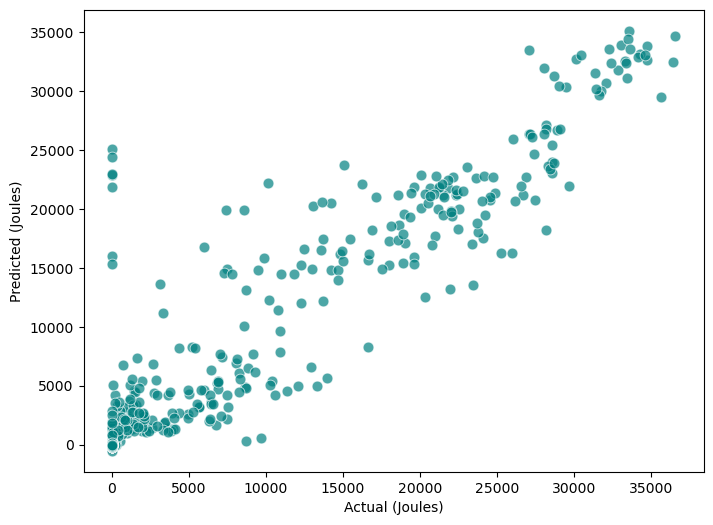

In [58]:
# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='Actual (Joules)', y='Predicted (Joules)', data=comparison_df, color='teal', alpha=0.7, s=60)

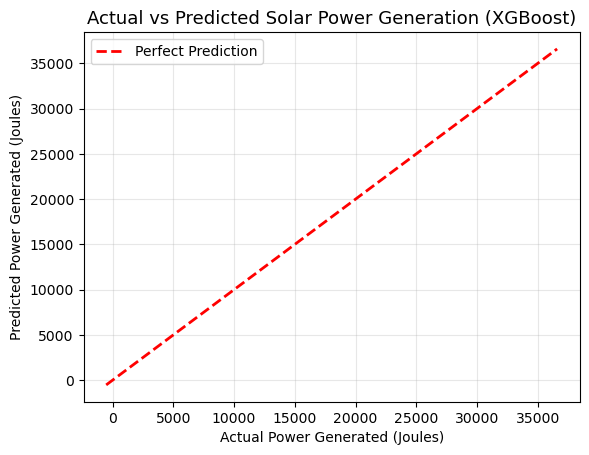

In [59]:
# Diagonal reference line (Perfect prediction)
plt.plot([comparison_df.min().min(), comparison_df.max().max()],
         [comparison_df.min().min(), comparison_df.max().max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("Actual vs Predicted Solar Power Generation (XGBoost)", fontsize=13)
plt.xlabel("Actual Power Generated (Joules)")
plt.ylabel("Predicted Power Generated (Joules)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
# some sample of comparisons actual vs predicted data variance
print("🔹 Sample Comparison:")
print(comparison_df.head(10))

🔹 Sample Comparison:
   Actual (Joules)  Predicted (Joules)
0            21804        21755.101562
1             2065         2427.854492
2                0           13.613264
3             5654         3160.135742
4             3621         1404.894165
5            27072        26354.302734
6                0          -67.819740
7                0          -46.527100
8                0          -83.225922
9                0          -15.301355


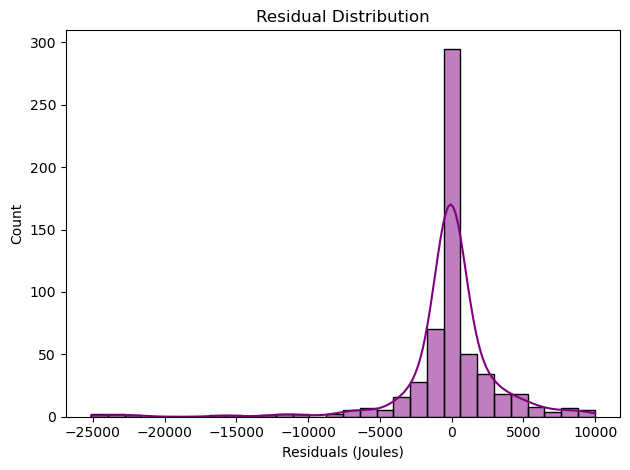

In [61]:
plt.subplot(1,1,1)
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title("Residual Distribution")
plt.xlabel("Residuals (Joules)")
plt.tight_layout()
plt.show()

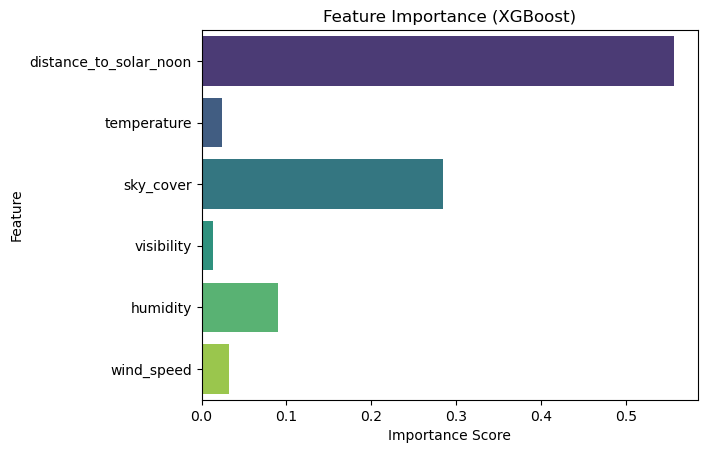

In [62]:
# feature importance
importances = best_xgb.feature_importances_
sns.barplot(x=importances, y=selected_features, palette='viridis')
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()